# Transfer learning and fine-tuning

### Reusing a network that was trained for something else

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why early layers transfer and late ones do not. The difference between feature extraction and fine-tuning, and how the two compare against training from scratch. How little labelled data you need before transfer stops being worth it. And why the strategy the textbooks call the safe one came last here |
| **You should already know** | [08-02 A convolutional network, layer by layer](../02-a-cnn-layer-by-layer/) |
| **Dataset** | Fashion-MNIST, split into two separate five-class tasks |
| **Runtime** | Four to six minutes on a laptop CPU, about one on a GPU |
| **Next** | [08-06 Image segmentation](../06-image-segmentation/) |

---

## 1. The idea

Training a network from random weights takes a lot of labelled examples. Most
real problems do not have a lot of labelled examples. Somebody wants to sort
photographs of their own products, or find one defect on one production line,
and they have a few hundred pictures.

Transfer learning is the answer that made deep learning usable outside large
labs. Take a network someone already trained on a big task, keep its weights,
throw away the last layer, put a new one on top for your classes, and carry on
training. You start from a model that already knows how to look at pictures
instead of from noise.

The reason this works is worth stating carefully, because it is the reason for
everything else in this notebook. The first thing a vision network learns is not
"cat". It is edges. Then corners and blobs, then textures, then object parts,
and only at the very end the categories it was scored on. Edges and textures are
properties of images, not of a label set. They are as useful for sorting X-rays
as they are for sorting dogs, so they carry over. The last layer, which has been
pushed to separate exactly the classes of the source task, carries over least.

**How I set this up.** The honest demonstration would pull an ImageNet-trained
network off the internet, and the cell below tries. But a notebook that only
runs when the network is up is a notebook that stops running, so the whole
experiment here is self-contained: I split Fashion-MNIST into two tasks that
share no classes, train a source model on the first five, and transfer it to the
other five. If the pretrained weights do load, I use them for one picture where
they make the point better than I can.

Know what that substitution costs, because it changes the answer. A source task
made of five clothing categories is small and narrow. The famous transfer results
come from backbones trained on enormous and varied photograph collections, and a
backbone trained on a handful of garment types has learned much less that carries
anywhere else. The mechanism I am demonstrating is the same one; the size of the
payoff is not. In this notebook the payoff came out small, and one of the two
transfer strategies came out behind the baseline it is supposed to beat. I kept
the measurements and rewrote the story around them, which is the deal this book
makes.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

train_set = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]
print(f"{len(train_set):,} training images, {len(test_set):,} test images, 28x28 greyscale")

torch 2.11.0+cu128 on cuda


60,000 training images, 10,000 test images, 28x28 greyscale


In [2]:
# Two tasks that share no labels. The source task gets all its data; the target
# task is the one I will starve of examples on purpose.
SOURCE_CLASSES = [0, 1, 2, 3, 4]
TARGET_CLASSES = [5, 6, 7, 8, 9]


class Relabelled(torch.utils.data.Dataset):
    """Same images, labels renumbered so a five-class task runs 0 to 4."""

    def __init__(self, base, classes):
        self.base = base
        self.lookup = {original: new for new, original in enumerate(classes)}

    def __len__(self):
        return len(self.base)

    def __getitem__(self, position):
        image, label = self.base[position]
        return image, self.lookup[int(label)]


def indices_for(dataset, classes):
    """Positions in `dataset` whose label is one of `classes`."""
    labels = torch.as_tensor(dataset.targets)
    keep = torch.isin(labels, torch.tensor(classes))
    return keep.nonzero(as_tuple=True)[0].tolist()


def split(dataset, classes):
    return Subset(Relabelled(dataset, classes), indices_for(dataset, classes))


source_train = split(train_set, SOURCE_CLASSES)
source_test = split(test_set, SOURCE_CLASSES)
target_pool = split(train_set, TARGET_CLASSES)
target_test = split(test_set, TARGET_CLASSES)

# Labels of the target pool, read from the raw targets so nothing has to be decoded.
target_pool_labels = (np.asarray(torch.as_tensor(train_set.targets))[
    indices_for(train_set, TARGET_CLASSES)] - TARGET_CLASSES[0])

source_train_loader = DataLoader(source_train, batch_size=256, shuffle=True)
source_test_loader = DataLoader(source_test, batch_size=1000)
target_test_loader = DataLoader(target_test, batch_size=1000)

print("source task :", ", ".join(CLASSES[c] for c in SOURCE_CLASSES),
      f"({len(source_train):,} training images)")
print("target task :", ", ".join(CLASSES[c] for c in TARGET_CLASSES),
      f"({len(target_pool):,} available, but I will use a fraction)")

source task : T-shirt, trouser, pullover, dress, coat (30,000 training images)
target task : sandal, shirt, sneaker, bag, boot (30,000 available, but I will use a fraction)


No garment appears in both rows. Whatever transfers is not memorised labels.


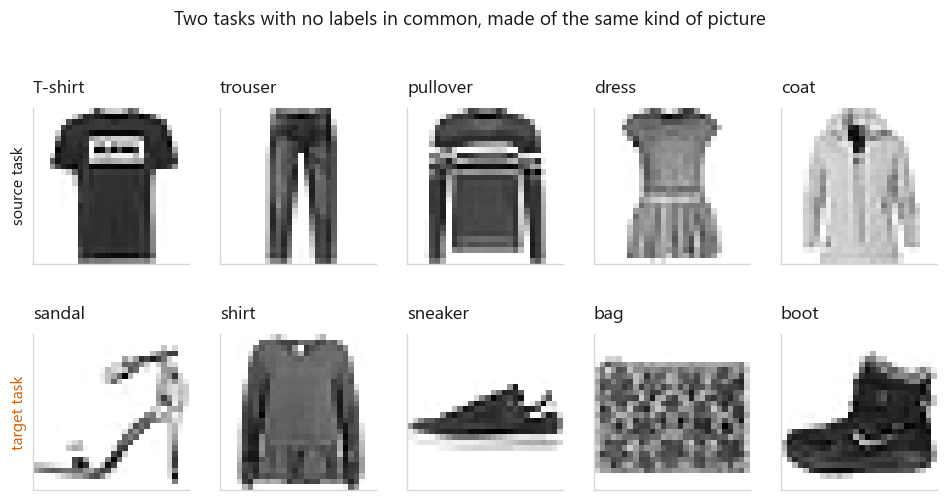

In [3]:
first_of = {c: int(np.flatnonzero(np.asarray(torch.as_tensor(train_set.targets)) == c)[0])
            for c in range(10)}

fig, axes = plt.subplots(2, 5, figsize=(10.6, 4.9))
for column, (source_class, target_class) in enumerate(zip(SOURCE_CLASSES, TARGET_CLASSES)):
    for row, class_index in enumerate([source_class, target_class]):
        ax = axes[row, column]
        ax.imshow(train_set[first_of[class_index]][0].squeeze(), cmap="gray_r")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        style.title(ax, CLASSES[class_index])
        ax.title.set_fontsize(9.5)
        ax.title.set_color(style.MUTED)
axes[0, 0].set_ylabel("source task", fontsize=10.5, color=style.INK)
axes[1, 0].set_ylabel("target task", fontsize=10.5, color=style.HIGHLIGHT)
fig.suptitle("Two tasks with no labels in common, made of the same kind of picture",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-two-tasks.png")

print("No garment appears in both rows. Whatever transfers is not memorised labels.")

## 2. What transfers and what does not

A trained network is a stack of representations, and they are not equally
reusable. The first convolution sees raw pixels and can only learn things that
are visible in a 3x3 window: an edge, a corner, a spot of contrast. That layer
would look almost the same if I had trained it on faces, or on satellite tiles,
or on chest scans, because those are all pictures and pictures are made of
edges. The second layer combines edges into small shapes. By the time you reach
the layer feeding the classifier, every unit has been shaped by the pressure to
separate the source classes specifically, and its meaning is something like
"trouser-ness". That last part is what does not transfer.

So the practical question is where to cut. Everything below the cut is copied
from the source model and frozen; everything above is fresh and trained on the
target. I will train the source model first, then cut at each depth and measure.

In [4]:
class SmallCNN(nn.Module):
    """The network from 08-02, split into named stages so I can copy them one by one."""

    def __init__(self, n_classes=5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.embed = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU())
        self.head = nn.Linear(64, n_classes)

    def forward(self, x):
        return self.head(self.embed(self.block2(self.block1(x))))


# Deliberately no batch norm. Frozen batch-norm layers keep updating their running
# statistics unless you also switch them to eval mode, and that gotcha would
# quietly muddy every measurement below.
STAGES = ["block1", "block2", "embed"]


def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += len(yb)
    return correct / total


torch.manual_seed(SEED)
source_model = SmallCNN(len(SOURCE_CLASSES)).to(device)
optimiser = torch.optim.SGD(source_model.parameters(), lr=0.05, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

started = time.perf_counter()
for _ in range(6):
    source_model.train()
    for xb, yb in source_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimiser.zero_grad()
        loss_fn(source_model(xb), yb).backward()
        optimiser.step()

SOURCE_ACCURACY = accuracy(source_model, source_test_loader)
print(f"source model: {SOURCE_ACCURACY:.4f} on its own five classes, "
      f"trained in {time.perf_counter() - started:.0f} seconds")
print("This is the model everything below inherits from.")

source model: 0.9222 on its own five classes, trained in 38 seconds
This is the model everything below inherits from.


In [5]:
# The only part of this notebook that wants the internet. It is decoration: if it
# fails, one panel of one figure disappears and nothing else changes.
imagenet_filters = None
try:
    from torchvision.models import resnet18, ResNet18_Weights

    pretrained = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    imagenet_filters = pretrained.conv1.weight.detach().cpu()[:16]
    print("ImageNet weights loaded, so I can show a real pretrained first layer too")
except Exception as error:
    print(f"no pretrained weights this run ({type(error).__name__}) - "
          "carrying on with the source model trained above")

ImageNet weights loaded, so I can show a real pretrained first layer too


In [6]:
def balanced_subset(pool, labels, n, seed=SEED):
    """`n` target examples, the same number per class, nested as `n` grows."""
    rng = np.random.default_rng(seed)
    per_class = n // len(np.unique(labels))
    chosen = np.concatenate([rng.permutation(np.flatnonzero(labels == c))[:per_class]
                             for c in np.unique(labels)])
    return Subset(pool, rng.permutation(chosen).tolist())


STEPS = 400   # every run gets the same number of gradient updates, so the only
BATCH = 64    # thing being compared is where the weights started


def target_run(n_train, *, copy_stages=0, freeze_copied=False, head_lr=0.05,
               backbone_scale=0.1, steps=STEPS, seed=SEED, check_every=None):
    """Train one model on the target task and return it with its test accuracy.

    `copy_stages` says how many stages are inherited from the source model,
    `freeze_copied` whether they are held fixed, and `backbone_scale` how much
    slower the inherited weights move when they are not frozen.
    """
    torch.manual_seed(seed)
    model = SmallCNN(len(TARGET_CLASSES)).to(device)
    for name in STAGES[:copy_stages]:
        getattr(model, name).load_state_dict(getattr(source_model, name).state_dict())
        if freeze_copied:
            for parameter in getattr(model, name).parameters():
                parameter.requires_grad = False

    copied = [p for name in STAGES[:copy_stages] for p in getattr(model, name).parameters()]
    fresh = [p for name in STAGES[copy_stages:] for p in getattr(model, name).parameters()]
    fresh += list(model.head.parameters())

    groups = [{"params": fresh, "lr": head_lr}]
    if copied and not freeze_copied:
        groups.append({"params": copied, "lr": head_lr * backbone_scale})
    optimiser = torch.optim.SGD(groups, momentum=0.9)
    schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=steps)
    loss_fn = nn.CrossEntropyLoss()

    subset = balanced_subset(target_pool, target_pool_labels, n_train, seed=seed)
    loader = DataLoader(subset, batch_size=min(BATCH, len(subset)), shuffle=True,
                        generator=torch.Generator().manual_seed(seed))

    history = {"step": [], "acc": []}
    step = 0
    model.train()
    while step < steps:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimiser.step()
            schedule.step()
            step += 1
            if check_every and step % check_every == 0:
                history["step"].append(step)
                history["acc"].append(accuracy(model, target_test_loader))
                model.train()
            if step >= steps:
                break
    return model, accuracy(model, target_test_loader), history


print(f"every target run: {STEPS} updates, batch {BATCH}, same seed")

# The noise scale for everything below. Every accuracy in this notebook is a
# proportion measured on the same target test set, so one standard error is
# sqrt(p(1-p)/n). One seed cannot separate two settings whose gap is inside a
# couple of these, and several of the gaps below are.
TEST_N = len(target_test)
NOISE = (0.9 * 0.1 / TEST_N) ** 0.5
print(f"target test set: {TEST_N:,} images, so one standard error near 90% "
      f"accuracy is {NOISE:.4f}")
print(f"gaps under about {2 * NOISE:.3f} are not resolved by this experiment")

every target run: 400 updates, batch 64, same seed
target test set: 5,000 images, so one standard error near 90% accuracy is 0.0042
gaps under about 0.008 are not resolved by this experiment


In [7]:
# Cut the source model at each depth, freeze everything below the cut, train
# everything above it on the same small target set.
DEPTH_N = 500
depth_names = ["nothing (from scratch)", "block1", "block1 + block2",
               "block1 + block2 + embed"]
depth_scores = []
for depth in range(len(STAGES) + 1):
    _, score, _ = target_run(DEPTH_N, copy_stages=depth, freeze_copied=True)
    depth_scores.append(score)
    print(f"copied and frozen: {depth_names[depth]:<24} accuracy {score:.4f}")

best = int(np.argmax(depth_scores))
runner_up = sorted(depth_scores)[-2]
print(f"\ntop two cuts differ by {depth_scores[best] - runner_up:.4f} "
      f"({(depth_scores[best] - runner_up) / NOISE:.1f} standard errors), so which "
      f"of the two is the best cut is not settled here")
print(f"best cut minus from scratch: {depth_scores[best] - depth_scores[0]:+.4f} "
      f"({(depth_scores[best] - depth_scores[0]) / NOISE:+.1f} SE)")
print(f"one stage too deep         : {depth_scores[-1] - depth_scores[best]:+.4f} "
      f"({(depth_scores[-1] - depth_scores[best]) / NOISE:+.1f} SE)")

copied and frozen: nothing (from scratch)   accuracy 0.9222


copied and frozen: block1                   accuracy 0.9344


copied and frozen: block1 + block2          accuracy 0.9366


copied and frozen: block1 + block2 + embed  accuracy 0.8634

top two cuts differ by 0.0022 (0.5 standard errors), so which of the two is the best cut is not settled here
best cut minus from scratch: +0.0144 (+3.4 SE)
one stage too deep         : -0.0732 (-17.3 SE)


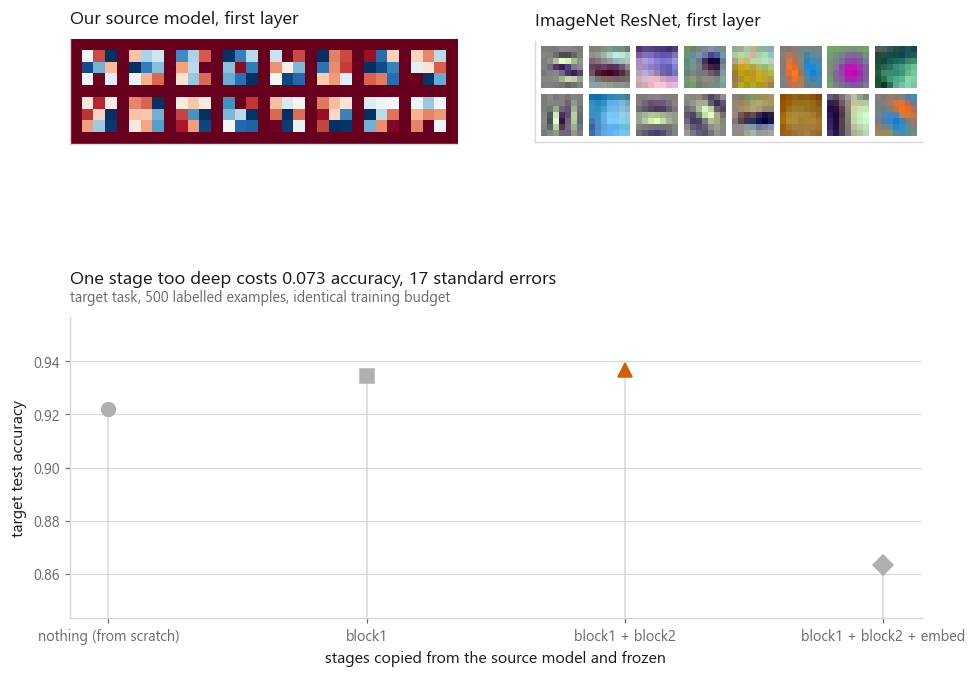

In [8]:
def montage(weights, cols=8, pad=1):
    """Tile a stack of filters into one image, each scaled symmetrically about zero."""
    array = weights.detach().cpu().numpy()
    n, channels, height, width = array.shape
    scale = np.abs(array).max(axis=(1, 2, 3), keepdims=True) + 1e-9
    array = array / scale * 0.5 + 0.5
    rows = int(np.ceil(n / cols))
    canvas = np.ones((rows * (height + pad) + pad, cols * (width + pad) + pad, channels))
    for i in range(n):
        row, column = divmod(i, cols)
        y, x = row * (height + pad) + pad, column * (width + pad) + pad
        canvas[y:y + height, x:x + width, :] = array[i].transpose(1, 2, 0)
    return canvas.squeeze(-1) if channels == 1 else canvas


fig = plt.figure(figsize=(10.0, 7.4))
grid = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.5], hspace=0.5)

if imagenet_filters is None:
    ax_ours = fig.add_subplot(grid[0, :])
else:
    ax_ours = fig.add_subplot(grid[0, 0])
    ax_them = fig.add_subplot(grid[0, 1])
    ax_them.imshow(montage(imagenet_filters))
    ax_them.set_xticks([]); ax_them.set_yticks([]); ax_them.grid(False)
    style.title(ax_them, "ImageNet ResNet, first layer")

ax_ours.imshow(montage(source_model.block1[0].weight), cmap="RdBu_r", vmin=0, vmax=1)
ax_ours.set_xticks([]); ax_ours.set_yticks([]); ax_ours.grid(False)
style.title(ax_ours, "Our source model, first layer")

ax_depth = fig.add_subplot(grid[1, :])
positions = np.arange(len(depth_scores))
depth_colours = style.spot(len(depth_scores), best)
ax_depth.vlines(positions, min(depth_scores) - 0.02, depth_scores,
                color=style.RULE, linewidth=1.0)
for position, score, colour, marker in zip(positions, depth_scores, depth_colours,
                                           style.MARKERS):
    ax_depth.plot(position, score, marker=marker, color=colour, markersize=9,
                  linestyle="none")
ax_depth.set_xticks(positions, depth_names, fontsize=9.5)
ax_depth.set_xlabel("stages copied from the source model and frozen")
ax_depth.set_ylabel("target test accuracy")
ax_depth.set_ylim(min(depth_scores) - 0.02, max(depth_scores) + 0.02)
style.title(ax_depth,
            f"One stage too deep costs {depth_scores[best] - depth_scores[-1]:.3f} "
            f"accuracy, {(depth_scores[best] - depth_scores[-1]) / NOISE:.0f} standard errors",
            f"target task, {DEPTH_N} labelled examples, identical training budget")
style.save(fig, FIG / "fig-02-what-transfers.png")

The first-layer filters are the argument in one picture. Most of them are
oriented light and dark bands, edge detectors, at various angles, with a few
blob detectors. Nobody asked for them and nothing about sandals or trousers is
written into them. If the ImageNet panel rendered, compare the two. One network
was trained on a million colour photographs of a thousand categories and the
other on thirty thousand small greyscale clothes, and their first layers are
recognisably the same idea. That similarity is the whole basis of transfer.

The dot plot underneath measures the payoff per depth, and the prints above give
each gap in standard errors so you can see which ones are real. The two
convolutional cuts are separated by a fraction of one standard error, so this
experiment does not tell you which of them to prefer, and I am not going to
pretend otherwise by pointing at the taller dot. Copying the convolutional
stages at all buys a small amount over from scratch. Copying the deepest stage
as well costs an order of magnitude more than that, and that gap is many
standard errors wide, so it is the one dot on the plot worth acting on.

The mechanism behind the drop is the point of section 2. The embed stage sits
directly under the classifier, so gradient pressure has spent the entire source
training shaping it to separate trousers from coats. Frozen, it hands the target
head a representation optimised for a question nobody is asking any more.

Keep that last dot in mind. Freezing everything up to the classifier is exactly
what feature extraction means in the next section, and on this plot it is already
the worst cut of the four, worse than starting from nothing at all. The
comparison below is going to confirm it rather than overturn it.

## 3. Three strategies compared

There are three things you can do with the same target task, and they differ
only in what starts trained and what is allowed to move.

| | |
|---|---|
| **From scratch** | Random weights, everything trainable. The baseline that ignores the source model, and the number both transfer strategies have to beat |
| **Feature extraction** | Copy the backbone, freeze it, train a new head. The backbone becomes a fixed function that turns images into vectors |
| **Fine-tuning** | Copy the backbone, train everything, but move the copied weights at a fraction of the head's learning rate |

The received wisdom about these three is that feature extraction is the safe
option when data is scarce, because it has hardly any trainable parameters and so
hardly anything to overfit, and that fine-tuning takes over later, once there is
enough data to steer the backbone without wrecking it. That wisdom is a
prediction about numbers, so I am going to run it rather than repeat it. Two
things to hold on to while you read the printout: feature extraction trains a
head on top of features that are stuck exactly as the source task left them, and
the from-scratch model is under no such constraint.

In [9]:
strategies = {
    "from scratch": dict(copy_stages=0, freeze_copied=False),
    "feature extraction": dict(copy_stages=len(STAGES), freeze_copied=True),
    "fine-tuning": dict(copy_stages=len(STAGES), freeze_copied=False, backbone_scale=0.1),
}

FIXED_N = 500
curves = {}
for name, options in strategies.items():
    model, score, history = target_run(FIXED_N, check_every=40, **options)
    curves[name] = history
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"{name:<20} accuracy {score:.4f}   trainable {trainable:>7,} of {total:,}")

from scratch         accuracy 0.9216   trainable 105,541 of 105,541


feature extraction   accuracy 0.8634   trainable     325 of 105,541


fine-tuning          accuracy 0.9348   trainable 105,541 of 105,541


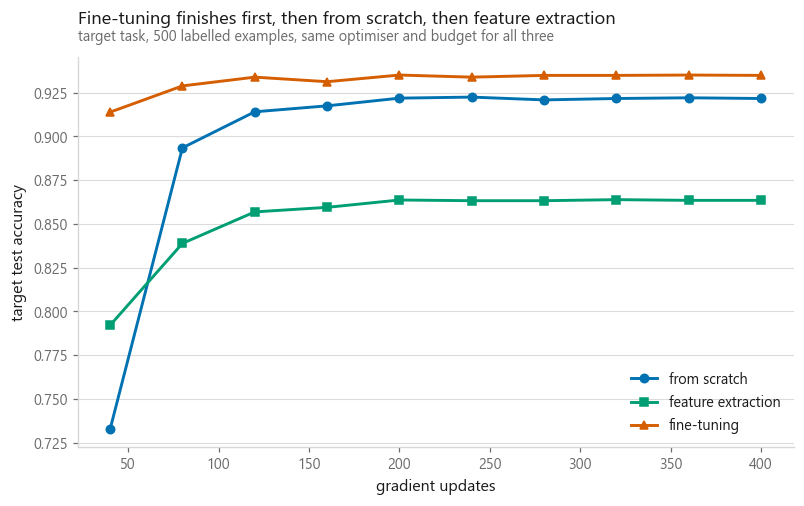

In [10]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
colours = [style.PALETTE[0], style.PALETTE[2], style.HIGHLIGHT]
for i, (name, history) in enumerate(curves.items()):
    ax.plot(history["step"], history["acc"], marker=style.MARKERS[i],
            color=colours[i], label=name)
ax.set_xlabel("gradient updates")
ax.set_ylabel("target test accuracy")
ax.legend(loc="lower right")
order = sorted(curves, key=lambda name: curves[name]["acc"][-1], reverse=True)
style.title(ax, f"{order[0].capitalize()} finishes first, then {order[1]}, then {order[2]}",
            f"target task, {FIXED_N} labelled examples, same optimiser and budget for all three")
style.save(fig, FIG / "fig-03-three-strategies.png")

Look at the left edge before you look at the right. Both transferred models are
already useful after a handful of updates, because the only thing they have to
learn is a linear map from features that already separate garments, while the
from-scratch model is still rediscovering edge detectors that were sitting in the
source model the whole time.

Then look at what happens next, because this is where the familiar story breaks.
The from-scratch curve catches the frozen one early in the budget and is never
behind it again. A head start is not the same thing as an advantage. Feature
extraction converges quickly because there is almost nothing to fit (the
printout above says how few of its weights can move), and then it stops, because
a frozen backbone cannot get any better at the target than it already is. The
from-scratch model starts from nothing and has no such ceiling, and small
greyscale clothing is an easy enough problem that the shared budget of updates is
enough for it to walk past. Only fine-tuning is still ahead at the end.

## 4. How little data before it stops helping

This is the question that decides whether transfer learning is worth your
afternoon. Transfer cannot help forever: with enough target data, a model
trained from scratch will learn its own features, tuned to the target rather
than inherited from someone else's task, and catch up. The useful question is
therefore about the size of the dataset: at what point does transfer stop
mattering?

I sweep the size of the target training set and run all three strategies at each
size. That is eighteen training runs, which is why each one is deliberately
cheap: the same small network and the same fixed number of updates throughout.
Sizes are nested, so the smallest set is contained in every larger one and the
curves are not moving because the sample changed.

In [11]:
SIZES = [50, 100, 250, 500, 1000, 2500]

rows = []
started = time.perf_counter()
for n in SIZES:
    for name, options in strategies.items():
        _, score, _ = target_run(n, **options)
        rows.append({"target examples": n, "strategy": name, "accuracy": score})

sweep = (pd.DataFrame(rows)
         .pivot(index="target examples", columns="strategy", values="accuracy")
         .loc[:, list(strategies)])
print(sweep.round(4).to_string())
print(f"\n{len(rows)} runs in {time.perf_counter() - started:.0f} seconds")

gap = sweep["fine-tuning"] - sweep["from scratch"]
print("\nfine-tuning minus from scratch, by target-set size:")
print(gap.round(4).to_string())
print(f"\ngap at {SIZES[0]} examples: {gap.iloc[0]:+.4f}   "
      f"gap at {SIZES[-1]}: {gap.iloc[-1]:+.4f}   "
      f"shrinkage: {gap.iloc[0] - gap.iloc[-1]:+.4f}")
resolved = gap.index[gap > 2 * NOISE].tolist()
print(f"sizes where the gap clears two standard errors ({2 * NOISE:.3f}): "
      f"{resolved if resolved else 'none'}")

# The deficit that matters most, because it runs against the standard advice.
deficit = sweep["from scratch"] - sweep["feature extraction"]
print(f"\nfrom scratch minus feature extraction, every size: "
      f"{deficit.min():+.4f} to {deficit.max():+.4f}")
print(f"smallest of those is {deficit.min() / NOISE:.0f} standard errors, "
      f"and the sign is the same at all {len(SIZES)} sizes")

reference = sweep["fine-tuning"].iloc[0]
matched = sweep.index[sweep["from scratch"] >= reference]
if len(matched):
    print(f"from scratch needs {matched[0]} examples to match what fine-tuning "
          f"reached with {SIZES[0]}")
else:
    print(f"from scratch never matches fine-tuning's {SIZES[0]}-example score "
          f"within this sweep")

strategy         from scratch  feature extraction  fine-tuning
target examples                                               
50                     0.8022              0.7172       0.8002
100                    0.8580              0.8064       0.8826
250                    0.8918              0.8330       0.9114
500                    0.9208              0.8634       0.9346
1000                   0.9378              0.8710       0.9426
2500                   0.9508              0.8738       0.9500

18 runs in 103 seconds

fine-tuning minus from scratch, by target-set size:
target examples
50     -0.0020
100     0.0246
250     0.0196
500     0.0138
1000    0.0048
2500   -0.0008

gap at 50 examples: -0.0020   gap at 2500: -0.0008   shrinkage: -0.0012
sizes where the gap clears two standard errors (0.008): [100, 250, 500]

from scratch minus feature extraction, every size: +0.0516 to +0.0850
smallest of those is 12 standard errors, and the sign is the same at all 6 sizes
from scratch nee

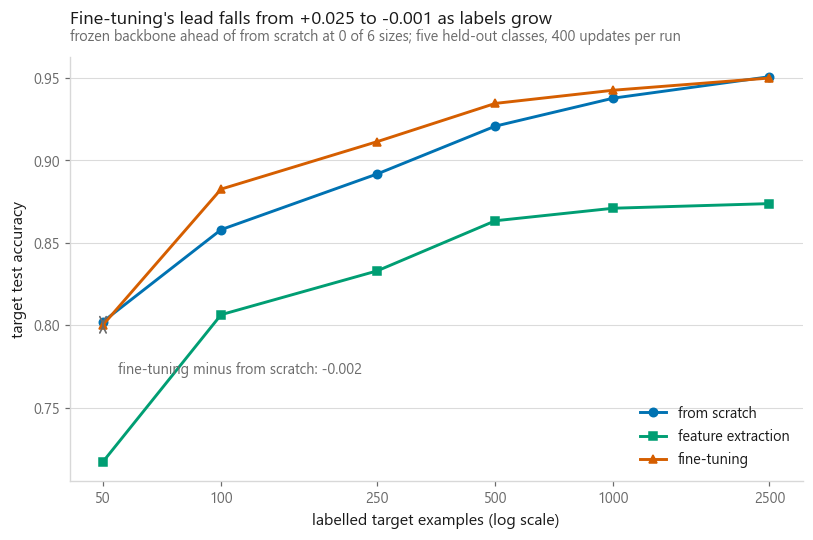

In [12]:
fig, ax = plt.subplots(figsize=(8.6, 5.0))
for i, name in enumerate(strategies):
    ax.plot(sweep.index, sweep[name], marker=style.MARKERS[i], color=colours[i],
            label=name)

ax.annotate("", xy=(SIZES[0], sweep["fine-tuning"].iloc[0]),
            xytext=(SIZES[0], sweep["from scratch"].iloc[0]),
            arrowprops=dict(arrowstyle="<->", color=style.MUTED, linewidth=1.1))
ax.annotate(f"fine-tuning minus from scratch: {gap.iloc[0]:+.3f}",
            xy=(SIZES[0], sweep.iloc[0].mean()),
            xytext=(10, 0), textcoords="offset points", va="center",
            fontsize=9.5, color=style.MUTED)

ax.set_xscale("log")
ax.set_xticks(SIZES, [str(s) for s in SIZES])
ax.minorticks_off()
ax.set_xlabel("labelled target examples (log scale)")
ax.set_ylabel("target test accuracy")
ax.legend(loc="lower right")
frozen_wins = int((sweep["feature extraction"] > sweep["from scratch"]).sum())
style.title(ax,
            f"Fine-tuning's lead falls from {gap.max():+.3f} to {gap.iloc[-1]:+.3f} "
            f"as labels grow",
            f"frozen backbone ahead of from scratch at {frozen_wins} of {len(SIZES)} "
            f"sizes; five held-out classes, {STEPS} updates per run")
style.save(fig, FIG / "fig-04-how-little-data.png")

This is the figure to keep, and it does not say what I went in expecting it to
say.

Start with the frozen model, because that is the surprise. Feature extraction
lost to training from scratch at every single size in the sweep, including the
smallest one, which is precisely where the standard advice says freezing is the
safe choice. This is the one comparison in the notebook I would defend from a
single seed, and the printed lines say why: the smallest of the six deficits is
still many standard errors wide, and the sign is the same at all six sizes.
Six coin flips landing the same way is not proof, but a consistent sign plus a
gap that size is a different situation from the thousandths elsewhere here.

The reason is not mysterious once the result is on the page. A frozen backbone
cannot adapt. Whatever the source task left in those features is what the target
task is stuck with, and the only thing that learns is the head on top. My source
task is a handful of clothing categories: small, narrow, and not especially
related to shoes and bags. The features it produced are partly right for the
target and there is no mechanism for fixing the rest. The from-scratch model is
free to learn features that suit the target instead, the network is small, the
images are small and greyscale, and the fixed budget of updates is enough for it
to do that. Freezing is a bet that the source features are already good enough.
Here that bet lost, at every size.

Now the fine-tuning curve, which did beat from scratch at every size. How much
it beat it by is the whole point, and here I have to be more careful. The
printed line names which sizes clear two standard errors and which do not. The
gaps at the right-hand end are a couple of thousandths on a five-thousand-image
test set, which is nothing: past a thousand labelled examples this experiment
says the two strategies are the same and I would not choose between them on
these numbers. The middle of the sweep is where the lead is large enough to
believe.

That shape is the one theory predicts, which is the reason to trust it more than
any single point on it. Transfer supplies features the target data would
otherwise have to pay for in labels. The fewer labels you have, the more that
subsidy is worth; add enough labels and the model builds better features itself,
because they are tuned to the target rather than inherited. The line under the
table says how many labelled examples from scratch needed in order to match what
fine-tuning reached with the smallest set. That is a real saving. It is also a
modest one, nothing like the dramatic reduction the usual telling implies.

So let me state the general lesson properly, because the folklore version is too
strong. How much transfer buys you depends on how rich the source was and how
related it is to your target. The famous results hold when several things are
true at once: the backbone was pretrained on a large and varied corpus, the
target domain looks like that corpus, the target data is genuinely scarce, and
the frozen features already separate the target classes. My source model fails
the first badly, and the frozen curve is what failing the last one looks like.
When those conditions hold, freezing is cheap and sensible. When they do not,
freezing is the risky choice and letting the weights move is what rescues it.

One caveat pointing the other way, because one result is one result. This is a
single small greyscale task with a deliberately weak source model, and the sign
of the feature-extraction comparison may well flip with an ImageNet-scale
backbone, where the frozen features are better than anything a scarce target set
could teach a network to build for itself. What does carry over is the habit: run
the three-way comparison on your own data instead of assuming the ordering, and
keep the from-scratch baseline in it, because it is the only line that tells you
whether transfer bought you anything at all.

## 5. Learning rates and forgetting

When you fine-tune, the copied weights are already close to something good. A
normal learning rate takes steps sized for a random initialisation, and those
steps are far too big here. Worse, the new head starts random, so its first
gradients are large and meaningless, and they flow straight back into the
backbone. A few hundred bad updates can undo everything the source training
bought before the target data has said anything useful.

So the backbone gets a smaller learning rate than the head, typically a tenth or
less. The standard recipe goes further: train the head alone for a short while,
then unfreeze, so that by the time gradients reach the backbone they mean
something.

The other cost of moving the backbone is **catastrophic forgetting**. The
features drift toward the target task, and the source task, which nobody is
measuring any more, quietly stops working. I can measure it directly: put the
original source head back on top of the fine-tuned backbone and score it on the
source test set. Nothing about the source head changed, so any loss is the
features having moved out from under it.

In [13]:
settings = [
    ("frozen backbone", dict(copy_stages=len(STAGES), freeze_copied=True)),
    ("backbone lr = head lr", dict(copy_stages=len(STAGES), backbone_scale=1.0)),
    ("backbone lr = head lr / 10", dict(copy_stages=len(STAGES), backbone_scale=0.1)),
    ("backbone lr = head lr / 100", dict(copy_stages=len(STAGES), backbone_scale=0.01)),
]

rows = []
for label, options in settings:
    tuned, score, _ = target_run(FIXED_N, **options)

    # The original source head, unchanged, on top of the moved backbone.
    probe = SmallCNN(len(SOURCE_CLASSES)).to(device)
    probe.load_state_dict(tuned.state_dict())
    probe.head.load_state_dict(source_model.head.state_dict())

    rows.append({"setting": label, "target accuracy": score,
                 "source accuracy after": accuracy(probe, source_test_loader)})

forgetting = pd.DataFrame(rows).set_index("setting")
print(f"source accuracy before any of this: {SOURCE_ACCURACY:.4f}\n")
print(forgetting.round(4).to_string())
print("\nthe last column is what the old task lost while the new one was learned")

source accuracy before any of this: 0.9222

                             target accuracy  source accuracy after
setting                                                            
frozen backbone                       0.8634                 0.9222
backbone lr = head lr                 0.9360                 0.5348
backbone lr = head lr / 10            0.9346                 0.8288
backbone lr = head lr / 100           0.9228                 0.9150

the last column is what the old task lost while the new one was learned


The two columns want reading differently, because one of them has a large
effect in it and the other does not.

The target column is nearly flat across the three unfrozen rows. Hold it against
the two standard errors printed at the top of the notebook before ranking the
learning rates: this experiment does not tell you that a tenth beats a full rate
on the target task, and I would not build a recipe on that gap. What it does
show, and by a wide margin, is the distance from the frozen row up to any of the
other three. Letting the copied weights move at all, however gently, was worth
more than any amount of care about how fast they move.

The source column is where the effect is large enough to act on, and it moves
monotonically: the faster the backbone was allowed to move, the less of the old
task survives. That is the whole argument for a reduced backbone rate. It is not
that a full rate hurts the new task, which the numbers here cannot show. It is
that a full rate spends the old task to buy nothing measurable. The frozen row is
the sanity check: it has to land exactly on the source accuracy printed above,
because those weights never moved.

For most work the forgetting does not matter, because you only care about the
new task. It matters when one model has to keep serving several tasks, or when
you fine-tune the same base model repeatedly and each round erases the last.
The cheap defences are to keep the source weights on disk, to freeze the lower
stages, and to mix a little source data back into training.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You have a small labelled dataset and somebody has already trained a model on a large, varied collection of similar input. The size and breadth of the source is what decides whether any of this pays |
| **Feature extraction** | Freeze the backbone, train a new head. Fewest trainable parameters, lowest ceiling. It is a bet that the source features are already good enough as they are, and it lost that bet here at every dataset size |
| **Fine-tuning** | Unfreeze the backbone at a fraction of the head's learning rate. Higher ceiling, and the only strategy in this notebook that beat training from scratch |
| **From scratch** | The baseline, not the fallback. Worth it when the target data is plentiful, when the source task is small or unrelated, or when the input is nothing like anything a public model has seen |
| **Before you trust either** | Run all three on your own data. The ordering depends on how rich and how related the source is, and checking costs one extra run |
| **Learning rate** | Head at the normal rate, backbone at a tenth or less. Warm the head up first, then unfreeze |
| **Where to cut** | Freeze from the bottom. Early layers are generic, late layers belong to the source task |
| **Watch out** | Frozen batch-norm layers still update their running statistics unless you also put them in eval mode |
| **Watch out** | Match the source preprocessing exactly: same resize, same channel order, same normalisation |

## What to remember

1. Early layers learn edges and textures, which belong to images in general. Late
   layers learn the source task's categories. The deeper the layer, the less it
   transfers, and copying one stage too deep cost more here than copying the
   right stages bought.
2. Fine-tuning's advantage over from scratch shrinks as the target set grows, and
   in this notebook it was modest even at the smallest sizes. How much transfer
   is worth depends on how large, how varied and how related the source task was.
   Mine was a handful of clothing categories, which is none of those things.
3. Freezing the backbone is not automatically the conservative choice. Feature
   extraction lost to training from scratch at every size measured here,
   including the smallest. A frozen backbone cannot adapt, so when the source
   features are only partly right you are stuck with them, while the from-scratch
   model is free to go and learn better ones.
4. Reduce the learning rate on copied weights not because a full rate hurts the
   new task, which this notebook could not show, but because it spends the old
   task to buy nothing. The source column of that table moves; the target column
   barely does.
5. Feature extraction is still the cheapest experiment you can run, so run it,
   as a diagnostic, not as a default. It tells you whether the source features are
   usable untouched. Here the answer was no, and unfreezing is what recovered it.
6. Always keep a from-scratch baseline in the comparison. It is the only line
   that says whether transfer bought you anything, and it is the one the folklore
   invites you to skip.
7. Print the standard error on your test set before you rank anything. Half the
   gaps in this notebook are inside it, and the half that are not are the only
   half worth a sentence.

If your problem is scarce labels rather than a scarce source model, the other
lever is [08-04 Data augmentation](../04-data-augmentation/), which manufactures
training examples instead of borrowing features. The backbones people actually
transfer from are the subject of
[08-03 Classic architectures](../03-classic-architectures/).

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-06 Image segmentation](../06-image-segmentation/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#TransferLearning` `#FineTuning` `#ComputerVision` `#PyTorch`
`#FashionMNIST` `#MachineLearning` `#Python` `#MLTutorial` `#AI`